# Persistence and Fault Tolerence

Persistence using LangGraph

In [4]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os

# new import for memory feature
from langgraph.checkpoint.memory import InMemorySaver
load_dotenv()

True

In [5]:
from langgraph.graph import add_messages
from typing import TypedDict,Annotated
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage],add_messages]

In [6]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0.7
)


In [8]:
class JokeState(TypedDict):
    topic : str
    joke : str
    explaination : str
    

In [9]:
def Genrate_joke(state : JokeState):
    prompt = f'gernate a joke on topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke' : response}

In [14]:
def Genrate_Explaination(state : JokeState):
    prompt = f'gernate a explaination for the joke {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explaination' : response}

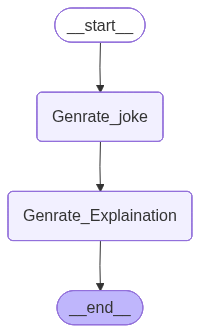

In [16]:

graph = StateGraph(JokeState)

# add nodes
graph.add_node('Genrate_joke' , Genrate_joke)
graph.add_node('Genrate_Explaination' , Genrate_Explaination)

# add edges

graph.add_edge(START , 'Genrate_joke')
graph.add_edge('Genrate_joke' , 'Genrate_Explaination')
graph.add_edge('Genrate_Explaination' , END)

checkpointer = InMemorySaver()
chatbot = graph.compile(checkpointer=checkpointer)
chatbot

In [17]:
config1 = {"configurable" : {"thread_id" : "1"}}
chatbot.invoke({'topic' : "pizza"}, config=config1)


{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.',
 'explaination': 'The joke "Why was the pizza in a bad mood? Because it was feeling a little crusty" is a play on words that uses a clever pun to create humor. \n\nThe setup for the joke asks about the pizza\'s emotional state, implying that it\'s experiencing some kind of negative feeling. The punchline "feeling a little crusty" has a double meaning. In one sense, "crusty" can describe someone or something that is irritable, gruff, or ill-tempered, which fits with the idea of being in a bad mood.\n\nHowever, "crusty" also literally describes the outer layer of a pizza, which is typically crispy and golden-brown. This wordplay relies on the multiple meanings of "crusty" to create a humorous connection between the pizza\'s emotional state and its physical characteristics.\n\nThe joke is funny because it takes an expected phrase ("feeling a little crusty" as a description of someone

In [21]:
# final state
chatbot.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explaination': 'The joke "Why was the pizza in a bad mood? Because it was feeling a little crusty" is a play on words that uses a clever pun to create humor. \n\nThe setup for the joke asks about the pizza\'s emotional state, implying that it\'s experiencing some kind of negative feeling. The punchline "feeling a little crusty" has a double meaning. In one sense, "crusty" can describe someone or something that is irritable, gruff, or ill-tempered, which fits with the idea of being in a bad mood.\n\nHowever, "crusty" also literally describes the outer layer of a pizza, which is typically crispy and golden-brown. This wordplay relies on the multiple meanings of "crusty" to create a humorous connection between the pizza\'s emotional state and its physical characteristics.\n\nThe joke is funny because it takes an expected phrase ("feeling a little crusty" as a des

In [ ]:
# intermediate state

list(chatbot.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explaination': 'The joke "Why was the pizza in a bad mood? Because it was feeling a little crusty" is a play on words that uses a clever pun to create humor. \n\nThe setup for the joke asks about the pizza\'s emotional state, implying that it\'s experiencing some kind of negative feeling. The punchline "feeling a little crusty" has a double meaning. In one sense, "crusty" can describe someone or something that is irritable, gruff, or ill-tempered, which fits with the idea of being in a bad mood.\n\nHowever, "crusty" also literally describes the outer layer of a pizza, which is typically crispy and golden-brown. This wordplay relies on the multiple meanings of "crusty" to create a humorous connection between the pizza\'s emotional state and its physical characteristics.\n\nThe joke is funny because it takes an expected phrase ("feeling a little crusty" as a de

In [22]:
config1 = {"configurable" : {"thread_id" : "2"}}
chatbot.invoke({'topic' : "mango juice"}, config=config1)


{'topic': 'mango juice',
 'joke': 'Why did the mango juice go to therapy?\n\nBecause it was feeling a little "sour" and wanted to work through some "juicy" issues.',
 'explaination': 'The joke "Why did the mango juice go to therapy?" is a play on words that uses puns to create a humorous effect. Here\'s a breakdown of the explanation:\n\n1. **Setup**: The joke starts by asking why the mango juice went to therapy, which is an unexpected and unusual scenario. This piques the listener\'s curiosity and sets the stage for the punchline.\n2. **Puns**: The punchline relies on two puns:\n\t* **"Sour"**: In this context, "sour" has a double meaning. Mango juice can be sour in taste, but the word "sour" can also describe a negative emotional state, such as feeling unhappy or discontent. The joke uses this wordplay to connect the literal taste of the mango juice to its emotional state.\n\t* **"Juicy"**: Similarly, "juicy" has a double meaning. Mango juice is a liquid with a high water content, ma

# Fault tolerance
* create fault tolernace using steps with delay of 30 second. our excution will start from the same step not from start

In [35]:
class CrashState(TypedDict):
    step1 : str
    step2 : str
    step3 : str
    input : str

In [36]:
import time
def step1(state : CrashState) -> CrashState:
    print("step 1 excuted")
    return {'step1' : 'Done', 'input' : state["input"]}

def step2(state : CrashState) -> CrashState:
    print("step 2 hanging manually interupt it")
    time.sleep(30)
    return {'step2' : 'Done'}

def step3(state : CrashState) -> CrashState:
    print("step 3 excuted")
    return {'step3' :'Done'}

In [37]:
# create Node 
graph = StateGraph(CrashState)

graph.add_node("step1",step1)
graph.add_node("step2",step2)
graph.add_node("step3",step3)


graph.add_edge(START,'step1')
graph.add_edge('step1','step2')
graph.add_edge('step2','step3')
graph.add_edge('step3',END)


Crash_graph = graph.compile(checkpointer=checkpointer)


In [38]:
try:
    print("running graph but manully interupt at step 2")
    Crash_graph.invoke({'input' : 'start'},config={'configurable' : {'thread_id' : 'thread-1'}})
except KeyboardInterrupt:
    print(" kernal manually interupted")

running graph but manully interupt at step 2
step 1 excuted
step 2 hanging manually interupt it
 kernal manually interupted


In [40]:
Crash_graph.get_state({'configurable' : {'thread_id' : 'thread-1'}})

StateSnapshot(values={'step1': 'Done', 'input': 'start'}, next=('step2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1402cf-773f-6ce9-8003-ce476a46af41'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-24T22:28:49.950794+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1402cf-7735-6d6d-8002-5039125057f3'}}, tasks=(PregelTask(id='a13c8c00-3700-e817-6498-a264b58249a4', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [41]:
list(Crash_graph.get_state_history({'configurable' : {'thread_id' : 'thread-1'}}))

[StateSnapshot(values={'step1': 'Done', 'input': 'start'}, next=('step2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1402cf-773f-6ce9-8003-ce476a46af41'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-24T22:28:49.950794+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1402cf-7735-6d6d-8002-5039125057f3'}}, tasks=(PregelTask(id='a13c8c00-3700-e817-6498-a264b58249a4', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1402cf-7735-6d6d-8002-5039125057f3'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-24T22:28:49.946725+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkp

In [ ]:
# Re run the graph to get final output
# the excution start from step 2

final_result = Crash_graph.invoke(None,{'configurable' : {'thread_id' : 'thread-1'}})
print("final state" , final_result)

step 2 hanging manually interupt it
step 3 excuted
final state {'step1': 'Done', 'step2': 'Done', 'step3': 'Done', 'input': 'start'}


In [47]:
list(Crash_graph.get_state_history({'configurable' : {'thread_id' : 'thread-1'}}))

[StateSnapshot(values={'step1': 'Done', 'step2': 'Done', 'step3': 'Done', 'input': 'start'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1402e7-afe4-6cef-8005-2e595c92453c'}}, metadata={'source': 'loop', 'step': 5, 'parents': {}}, created_at='2026-04-24T22:39:40.135492+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1402e7-afdc-6ef1-8004-f83851a6ee13'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'step1': 'Done', 'step2': 'Done', 'input': 'start'}, next=('step3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1402e7-afdc-6ef1-8004-f83851a6ee13'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2026-04-24T22:39:40.132258+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1402e6-91bd-60b5-8003-7e545dbd0484'}}, tasks=(PregelTask(id='00736c79-2881-4789-

# Restart from specific checkpoint

* Use checkpoint id to restart from specific step

In [45]:
final_result = Crash_graph.invoke(None,{'configurable' : {'thread_id' : 'thread-1','checkpoint_id' : '1f1402cf-76f5-6aff-8001-bca776014a7e' }})
print("final state" , final_result)

step 1 excuted
step 2 hanging manually interupt it
step 3 excuted
final state {'step1': 'Done', 'step2': 'Done', 'step3': 'Done', 'input': 'start'}
